# DeePTB vs DFTB+ EOS Benchmark

Benchmark electronic equation-of-state (EOS) curves for carbon BCC and graphene using DeePTB's SCC implementation against DFTB+ reference runs. Only the electronic energy is compared; total energy is kept for reference.

**Data and defaults**

- DeePTB structures: `dptb/tests/data/dftb/structs_eos/C_<STRUCT>/<scale>/POSCAR`
- DFTB+ reference EOS tables: `dptb/tests/data/dftb/structs_eos/dftbp_results/`
- Slater-Koster set: `dptb/tests/data/dftb/` (C-C.skf, etc.)
- Carbon setup mirrors test configuration: Pulay mixing, tuned k-mesh per structure, and `sigma_rep={C: 0.561}`.

Run the cells below to compute DeePTB EOS, align with DFTB+ electronic energies, and visualize both curves plus deltas.

In [5]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    pd = None

from IPython.display import display
from dptb.nn.dftb.dftb_scc import DFTBSCC

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120


In [6]:
# Shared configuration
SCALES = np.array([0.850, 0.900, 0.950, 1.000, 1.050, 1.100, 1.150], dtype=float)

# Data paths relative to project root - works when notebook is in examples/
# The test data is stored in dptb/tests/data/dftb/
_PROJECT_ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "dptb" / "tests" / "data" / "dftb").exists()), Path.cwd().resolve())
_DFTB_DATA = _PROJECT_ROOT / "dptb" / "tests" / "data" / "dftb"

STRUCT_ROOT = _DFTB_DATA / "structs_eos"
DFTBP_ROOT = STRUCT_ROOT / "dftbp_results"
DFTBP_EOS = {
    "BCC": DFTBP_ROOT / "eos_data_bcc.txt",
    "GRAPHENE": DFTBP_ROOT / "eos_data_gra.txt",
    "DIMER": DFTBP_ROOT / "potential_energy_data_dimer.txt",
}
ATOMS_PER_CELL = {"BCC": 1, "GRAPHENE": 2, "DIMER": 2}
SK_PATH = _DFTB_DATA

UNISK_SETUP = {
    "basis": {"C": ["2s", "2p"]},
    "nel_atom": {"C": 4},
    "sigma_rep": {"C": 0.561},
    "AtomicData_options": {"r_max": {"C": 4.2}},
    "tol": 1e-14,
    "mix_rate": 0.30,
    "max_iter": 1000,
    "Temp": 0.1,
    "smearing_method": "FD",
    "mixer": "pulay",
    "overlap": True,
    "smooth_ski": True,
}

STRUCT_SETTINGS = {
    # k-mesh follows the guidance from the original snippet
    "BCC": {"file_type": "POSCAR", "kmeshgrid": [20, 20, 20], "krotational_symmetry": True},
    "GRAPHENE": {"file_type": "POSCAR", "kmeshgrid": [100, 100, 1], "krotational_symmetry": True},
    "DIMER": {"file_type": "POSCAR", "kmeshgrid": [1, 1, 1], "krotational_symmetry": True},
}

In [7]:
def build_struct_paths(struct_type: str, file_type: str = "POSCAR", scales=SCALES):
    """Return the ordered POSCAR/CONTCAR paths for the selected structure type."""
    base = STRUCT_ROOT / f"C_{struct_type}"
    prefix = f"C_{struct_type.lower()}_"
    return [base / f"{prefix}{scale:.3f}" / file_type for scale in scales]


def load_dftbp_eos(struct_type: str):
    """Load DFTB+ EOS table (scale, volume, total, electronic)."""
    path = DFTBP_EOS[struct_type]
    data = np.genfromtxt(path, comments="#")
    return {
        "scale": data[:, 0],
        "volume": data[:, 1],
        "total_energy": data[:, 2],
        "electronic_energy": data[:, 3],
        "path": path,
    }


def run_unisk_eos(struct_type: str):
    """Compute DeePTB EOS for the requested structure type."""
    cfg = STRUCT_SETTINGS[struct_type]
    struct_paths = build_struct_paths(struct_type, file_type=cfg["file_type"])
    results = []

    for scale, struct in zip(SCALES, struct_paths):
        dftbscc = DFTBSCC(
            basis=UNISK_SETUP["basis"],
            sk_path=str(SK_PATH),
            overlap=UNISK_SETUP["overlap"],
            smooth_ski=UNISK_SETUP["smooth_ski"],
        )

        total_energy = dftbscc.get_total_energy(
            data=str(struct),
            nel_atom=UNISK_SETUP["nel_atom"],
            sigma_rep=UNISK_SETUP["sigma_rep"],
            kmeshgrid=cfg["kmeshgrid"],
            kgamma_center=True,
            krotational_symmetry=cfg["krotational_symmetry"],
            ktime_inversion_symmetry=True,
            tol=UNISK_SETUP["tol"],
            mix_rate=UNISK_SETUP["mix_rate"],
            max_iter=UNISK_SETUP["max_iter"],
            Temp=UNISK_SETUP["Temp"],
            AtomicData_options=UNISK_SETUP["AtomicData_options"],
            smearing_method=UNISK_SETUP["smearing_method"],
            mixer=UNISK_SETUP["mixer"],
        )

        results.append({
            "scale": float(scale),
            "electronic_energy": float(dftbscc.elec_totE),
            "total_energy": float(total_energy),
            "repulsive_energy": float(getattr(dftbscc, "total_rep_energy", 0.0)),
            "structure": str(struct),
        })
        print(f"{struct_type} scale {scale:.3f} -> elec {results[-1]['electronic_energy']:.6f} eV")

    return results


def make_comparison(struct_type: str, unisk_records, dftbp_data):
    """Assemble aligned arrays for DeePTB vs DFTB+ electronic energy."""
    atoms_per_cell = ATOMS_PER_CELL[struct_type]
    unisk_scale = np.array([r["scale"] for r in unisk_records], dtype=float)
    dftbp_scale = np.array(dftbp_data["scale"], dtype=float)
    if not np.allclose(unisk_scale, dftbp_scale, atol=1e-6):
        raise ValueError(f"Scale mismatch for {struct_type}: DeePTB {unisk_scale} vs DFTB+ {dftbp_scale}")

    table = {
        "scale": unisk_scale,
        "volume_A3": np.array(dftbp_data["volume"], dtype=float),
        "electronic_e_unisk": np.array([r["electronic_energy"] for r in unisk_records], dtype=float),
        "electronic_e_dftbp": np.array(dftbp_data["electronic_energy"], dtype=float),
        "atoms_per_cell": atoms_per_cell,
    }
    table["delta_eV"] = table["electronic_e_unisk"] - table["electronic_e_dftbp"]
    table["delta_eV_per_atom"] = table["delta_eV"] / atoms_per_cell
    return table


def display_table(struct_type: str, table):
    """Show the comparison table as a dataframe if pandas is available."""
    if pd is not None:
        frame = pd.DataFrame(table).set_index("scale")
        return display(frame.rename_axis("scale").style.format({
            "volume_A3": "{:.3f}",
            "electronic_e_unisk": "{:.6f}",
            "electronic_e_dftbp": "{:.6f}",
            "delta_eV": "{:.6f}",
            "delta_eV_per_atom": "{:.6f}",
            "atoms_per_cell": "{:d}",
        }))

    header = "scale   volume(A^3)   DeePTB_Eelec(eV)   DFTB+_Eelec(eV)   Delta(eV)   Delta(eV/atom)"
    print(f"{struct_type} electronic energy table (atoms per cell: {table['atoms_per_cell']})")
    print(header)
    for row in zip(
        table["scale"],
        table["volume_A3"],
        table["electronic_e_unisk"],
        table["electronic_e_dftbp"],
        table["delta_eV"],
        table["delta_eV_per_atom"],
    ):
        print(f"{row[0]:>6.3f} {row[1]:>12.3f} {row[2]:>18.6f} {row[3]:>17.6f} {row[4]:>10.6f} {row[5]:>15.6f}")


def plot_comparison(struct_type: str, table):
    """Plot EOS curves and their electronic-energy delta per atom."""
    scale = table["scale"]
    uni = table["electronic_e_unisk"]
    dftbp = table["electronic_e_dftbp"]
    delta = table["delta_eV_per_atom"]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

    axes[0].plot(scale, dftbp, "o-", label="DFTB+ electronic")
    axes[0].plot(scale, uni, "s--", label="DeePTB electronic")
    axes[0].set_title(f"{struct_type} electronic energy")
    axes[0].set_xlabel("Lattice scale")
    axes[0].set_ylabel("Electronic energy (eV)")
    axes[0].legend()

    axes[1].plot(scale, delta, "d-", color="C3")
    axes[1].axhline(0.0, color="k", lw=1, ls="--")
    axes[1].set_title("DeePTB - DFTB+ electronic energy per atom")
    axes[1].set_xlabel("Lattice scale")
    axes[1].set_ylabel("Delta (eV/atom)")


In [8]:
# Run DeePTB SCC and load DFTB+ reference EOS
dftbp_eos = {key: load_dftbp_eos(key) for key in STRUCT_SETTINGS}
unisk_eos = {}

for struct_type in STRUCT_SETTINGS:
    print(f"=== {struct_type} ===")
    unisk_eos[struct_type] = run_unisk_eos(struct_type)


=== BCC ===


Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'C': 4.2}
This is very dangerous, please make sure you know what you are doing.
/Users/aisiqg/Desktop/work/github/DeePTB/.venv/lib/python3.10/site-packages/torch/nested/__init__.py:107: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:180.)
  return torch._nested_tensor_from_tensor_list(ts, dtype, None, device, None)


BCC scale 0.850 -> elec -40.367435 eV


Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'C': 4.2}
This is very dangerous, please make sure you know what you are doing.


BCC scale 0.900 -> elec -41.965568 eV


...

GRAPHENE scale 1.100 -> elec -95.098432 eV


Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'C': 4.2}
This is very dangerous, please make sure you know what you are doing.
Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'C': 4.2}
This is very dangerous, please make sure you know what you are doing.
Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'C': 4.2}
This is very dangerous, please make sure you know what you are doing.
Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'C': 4.2}
This is very dangerous, please make sure you know what you are doing.
Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'C': 4.2}
This is very dangerous, please make sure you know what you are doing.
Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'C': 4.2}
This is very dangerous, please make su

GRAPHENE scale 1.150 -> elec -93.413870 eV
=== DIMER ===
DIMER scale 0.850 -> elec -94.730923 eV
DIMER scale 0.900 -> elec -92.906279 eV
DIMER scale 0.950 -> elec -91.199917 eV
DIMER scale 1.000 -> elec -89.618256 eV
DIMER scale 1.050 -> elec -88.164264 eV
DIMER scale 1.100 -> elec -86.836340 eV


Calculated charge deviates from target by more than q_tol=1e-06. Calculated: 8.000001273754812, Target: 8. Difference: 1.273755e-06
Calculated charge deviates from target by more than q_tol=1e-06. Calculated: 8.000001273796885, Target: 8. Difference: 1.273797e-06
Calculated charge deviates from target by more than q_tol=1e-06. Calculated: 8.000001273748895, Target: 8. Difference: 1.273749e-06
Calculated charge deviates from target by more than q_tol=1e-06. Calculated: 8.000001273785818, Target: 8. Difference: 1.273786e-06
Calculated charge deviates from target by more than q_tol=1e-06. Calculated: 8.000001273703864, Target: 8. Difference: 1.273704e-06
Calculated charge deviates from target by more than q_tol=1e-06. Calculated: 8.000001273706822, Target: 8. Difference: 1.273707e-06
Calculated charge deviates from target by more than q_tol=1e-06. Calculated: 8.00000127370978, Target: 8. Difference: 1.273710e-06
Calculated charge deviates from target by more than q_tol=1e-06. Calculated: 

DIMER scale 1.150 -> elec -85.629824 eV


,volume_A3,electronic_e_unisk,electronic_e_dftbp,atoms_per_cell,delta_eV,delta_eV_per_atom
scale,,,,,,
0.850000,4.107,-40.367435,-40.362700,1,-0.004735,-0.004735
0.900000,4.875,-41.965568,-41.968400,1,0.002832,0.002832
0.950000,5.734,-42.914189,-42.913300,1,-0.000889,-0.000889
1.000000,6.687,-43.362431,-43.359000,1,-0.003431,-0.003431
1.050000,7.742,-43.414475,-43.420000,1,0.005525,0.005525
1.100000,8.901,-43.179605,-43.188600,1,0.008995,0.008995
1.150000,10.171,-42.763596,-42.764100,1,0.000504,0.000504


,volume_A3,electronic_e_unisk,electronic_e_dftbp,atoms_per_cell,delta_eV,delta_eV_per_atom
scale,,,,,,
0.850000,64.713,-103.264987,-103.264800,2,-0.000187,-0.000094
0.900000,76.818,-101.790422,-101.789000,2,-0.001422,-0.000711
0.950000,90.345,-100.183828,-100.183200,2,-0.000628,-0.000314
1.000000,105.374,-98.508637,-98.508900,2,0.000263,0.000132
1.050000,121.984,-96.803810,-96.803800,2,-0.000010,-0.000005
1.100000,140.253,-95.098432,-95.098400,2,-0.000032,-0.000016
1.150000,160.261,-93.413870,-93.420100,2,0.006230,0.003115


,volume_A3,electronic_e_unisk,electronic_e_dftbp,atoms_per_cell,delta_eV,delta_eV_per_atom
scale,,,,,,
0.850000,1.079,-94.730923,-94.730900,2,-0.000023,-0.000011
0.900000,1.142,-92.906279,-92.906300,2,0.000021,0.000011
0.950000,1.206,-91.199917,-91.199900,2,-0.000017,-0.000009
1.000000,1.269,-89.618256,-89.618300,2,0.000044,0.000022
1.050000,1.333,-88.164264,-88.164300,2,0.000036,0.000018
1.100000,1.396,-86.836340,-86.836300,2,-0.000040,-0.000020
1.150000,1.460,-85.629824,-85.629800,2,-0.000024,-0.000012


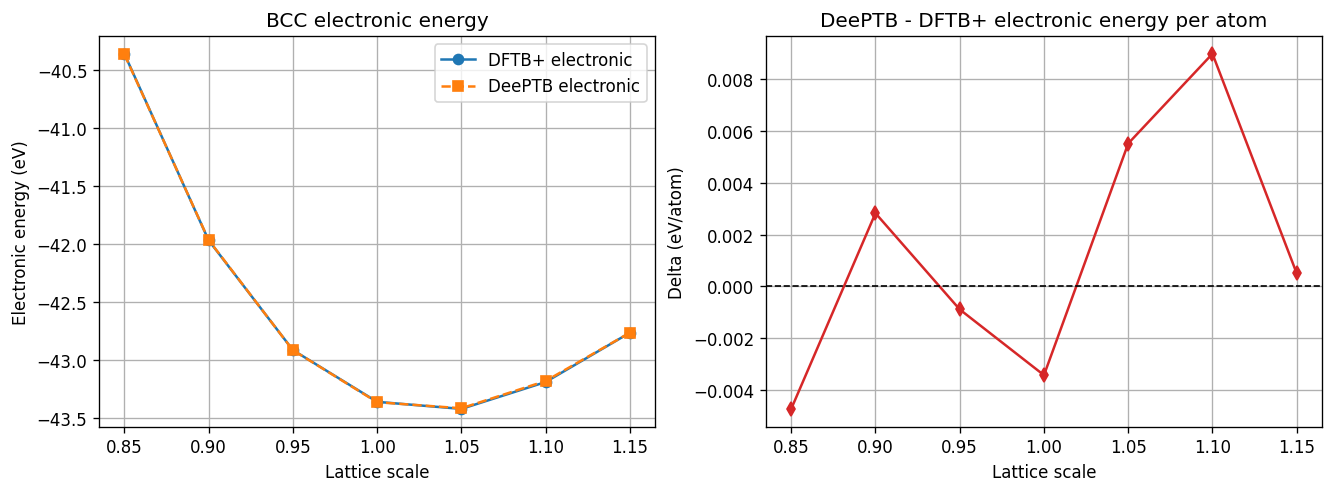

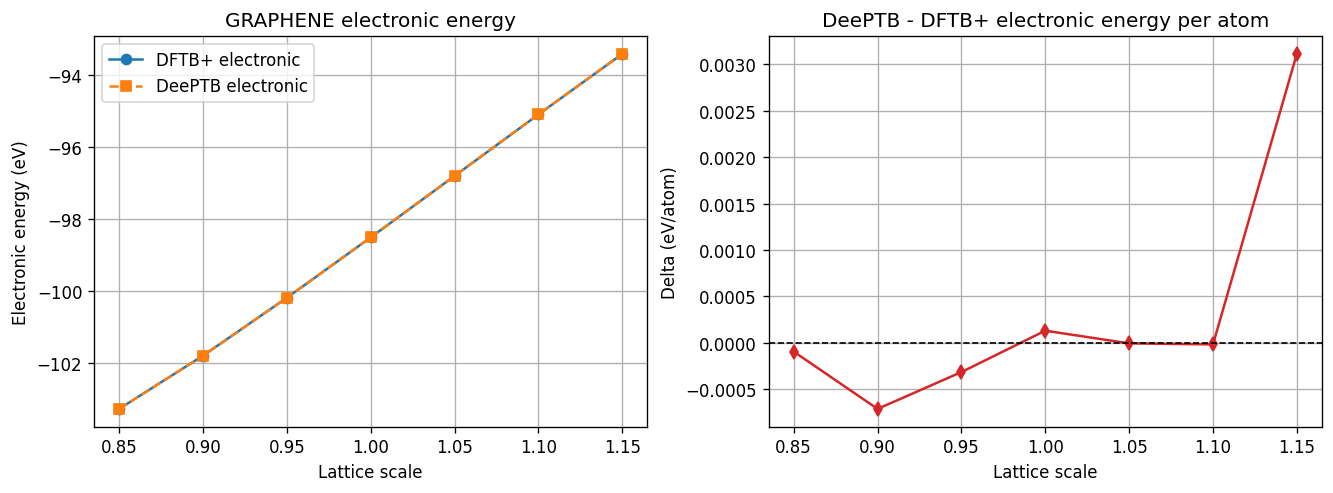

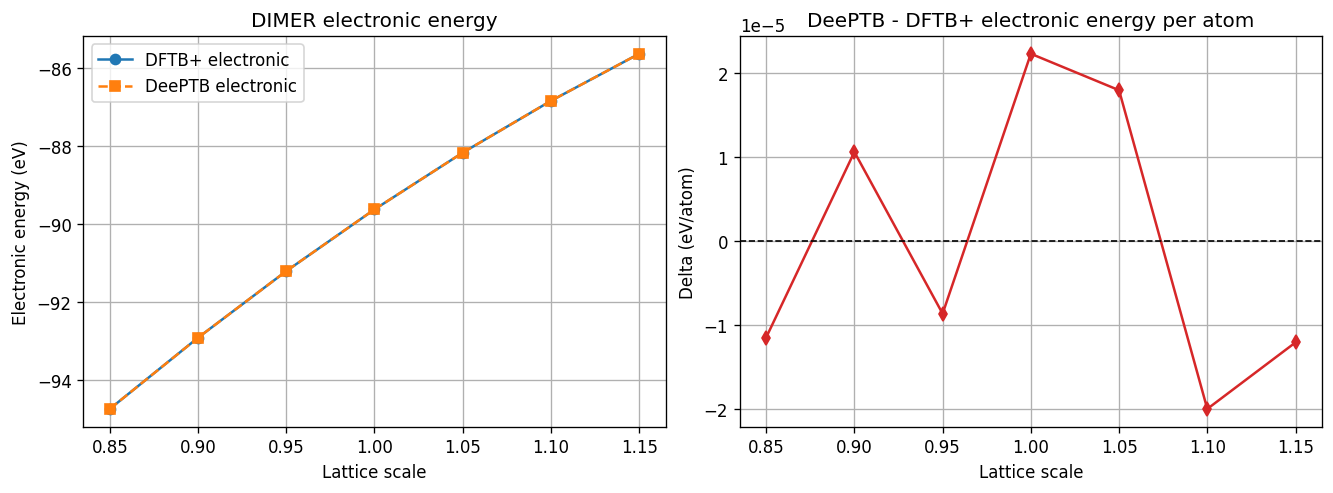

In [10]:
# Build comparison tables and visualize
tables = {}
for struct_type in STRUCT_SETTINGS:
    tables[struct_type] = make_comparison(struct_type, unisk_eos[struct_type], dftbp_eos[struct_type])
    display_table(struct_type, tables[struct_type])
    plot_comparison(struct_type, tables[struct_type])

plt.show()
